### **Statisctial Analysis on the Data**

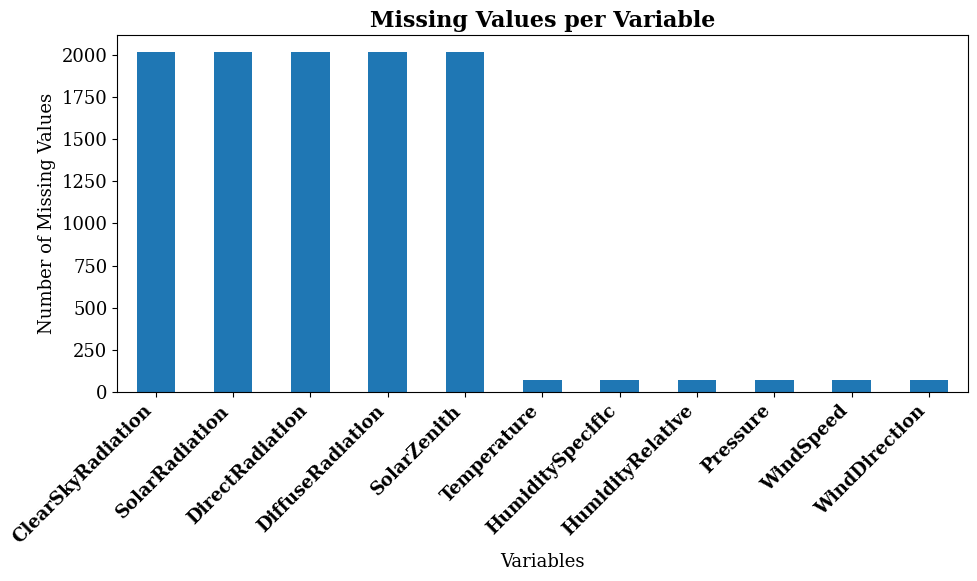

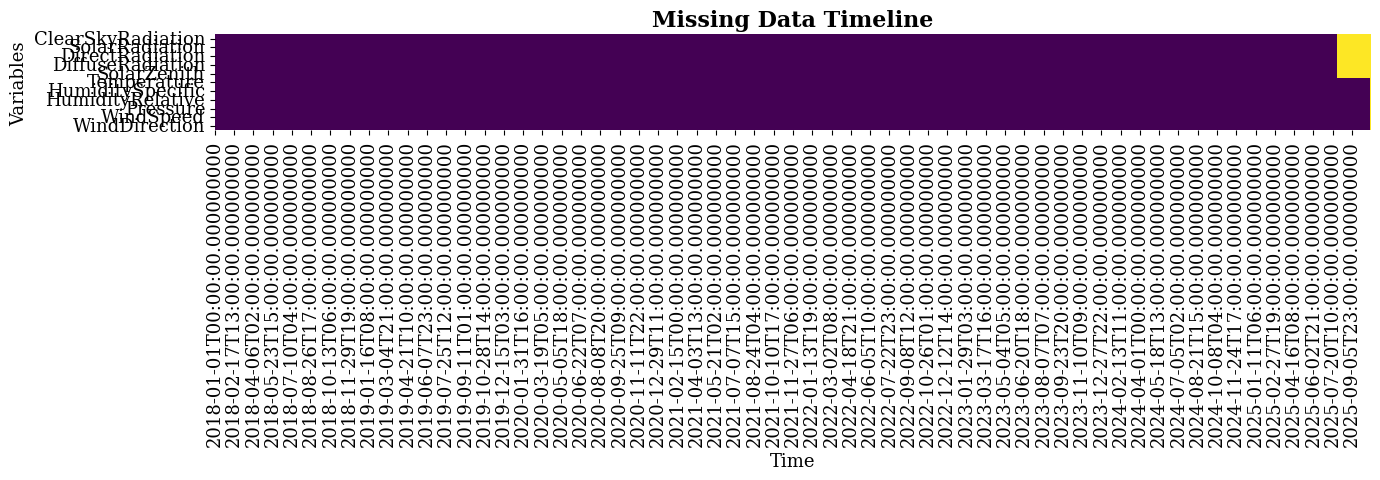


🔍 Checking missing values before fill:
ClearSkyRadiation    2016
SolarRadiation       2016
DirectRadiation      2016
DiffuseRadiation     2016
SolarZenith          2016
Temperature            72
HumiditySpecific       72
HumidityRelative       72
Pressure               72
WindSpeed              72
WindDirection          72
dtype: int64

✅ Missing values filled using 2018–2024 climatology

📊 Basic Descriptive Statistics:
                     count        mean         std    min     25%     50%  \
ClearSkyRadiation  68448.0  231.955154  304.082804   0.00    0.00   11.12   
SolarRadiation     68448.0  200.427805  275.379165   0.00    0.00    9.52   
DirectRadiation    68448.0  158.136201  243.170856   0.00    0.00    0.00   
DiffuseRadiation   68448.0   90.976418  118.266235   0.00    0.00   11.26   
SolarZenith        68448.0   72.461867   22.730187  10.59   56.19   88.07   
Temperature        68448.0   25.099201    9.608141   0.32   17.76   26.23   
HumiditySpecific   68448.0   10.4921

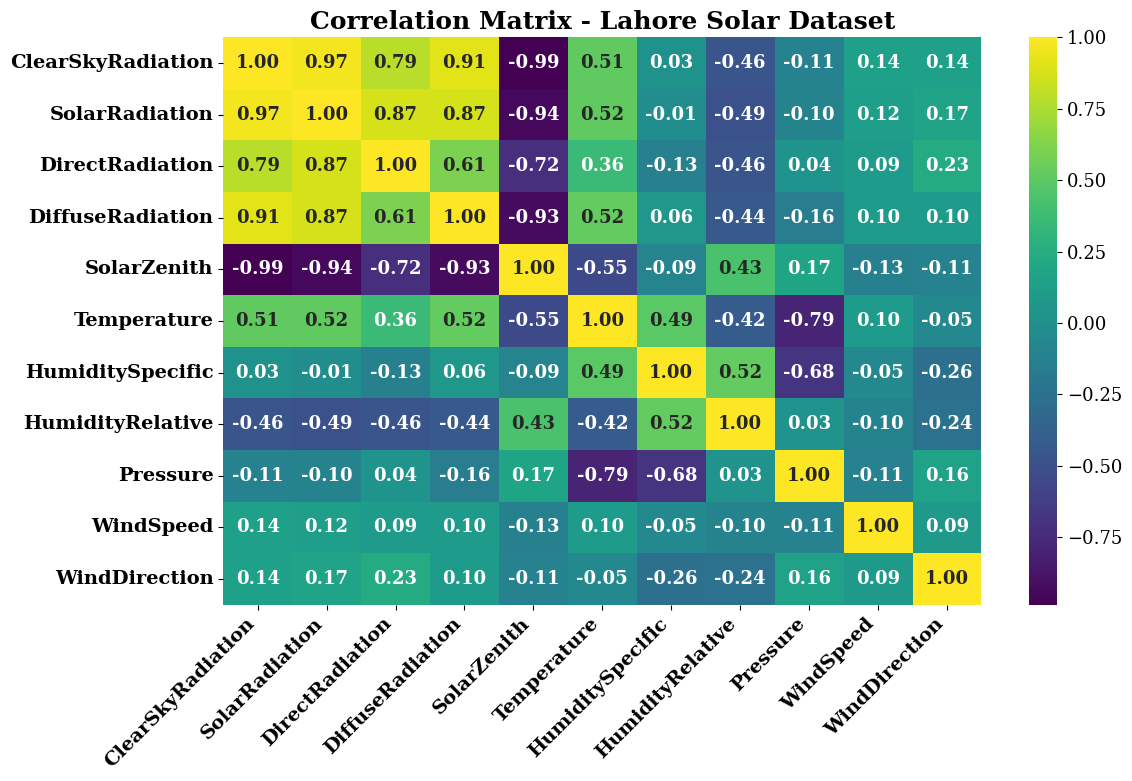

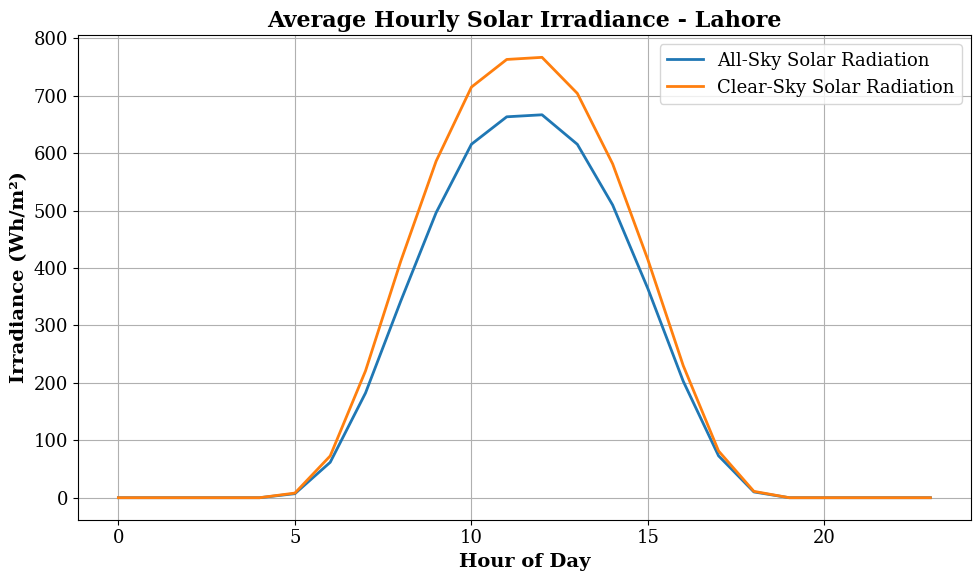

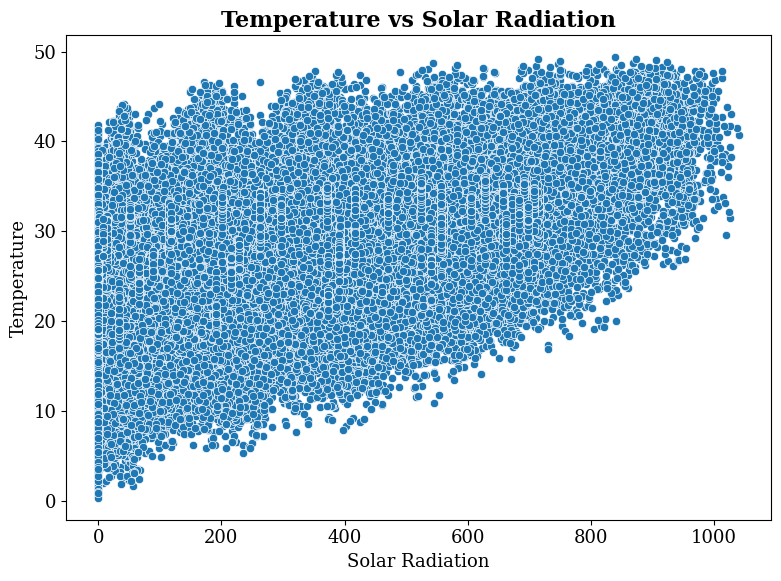

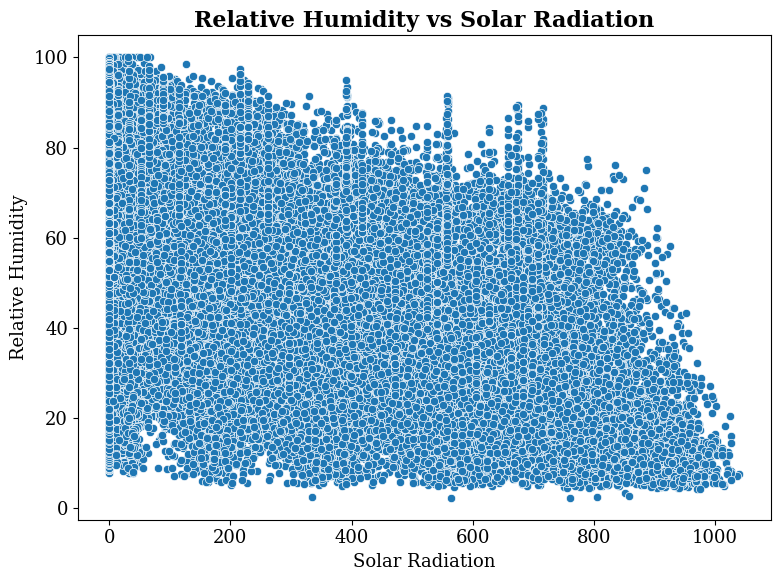

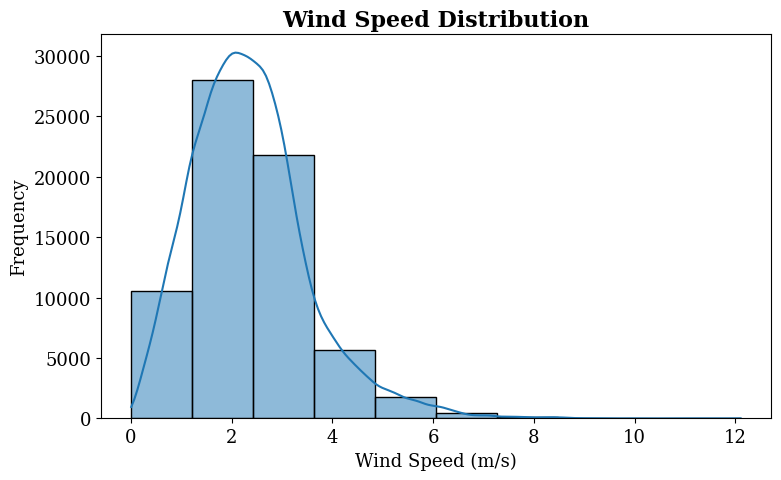

/tmp/ipykernel_248/1177730683.py:228: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean(numeric_only=True)


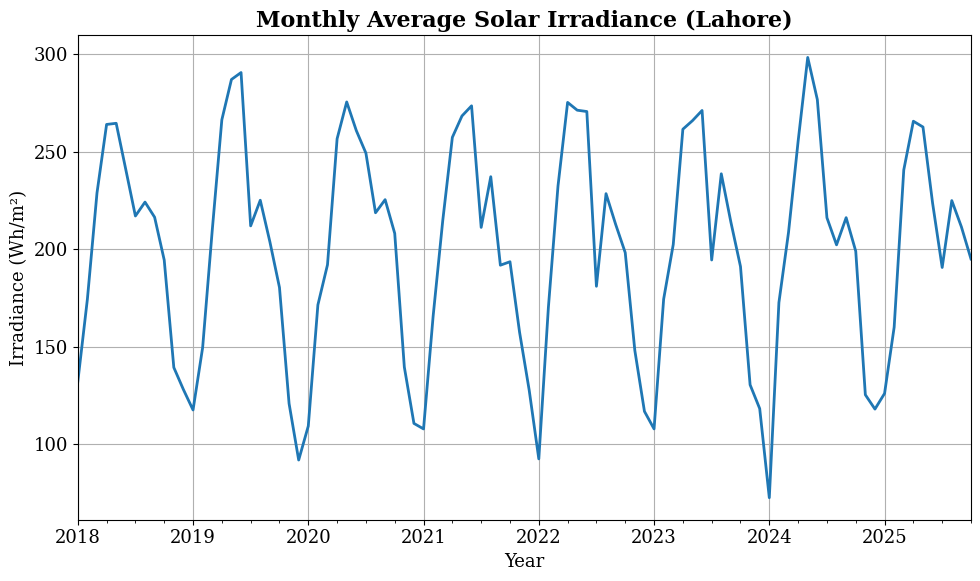


✅ Cleaned dataset saved as 'lahore_hourly_climatology_filled.csv'


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Global Plot Settings (Apply Once)
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

annot_settings = {"fontsize": 13, "fontweight": "bold"}

# ==========================================================
# 1️⃣ Load and Prepare the Data
# ==========================================================

df = pd.read_csv('NASA-Lahore-Hourly-Data.csv')

df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M')
df.set_index('datetime', inplace=True)

df.replace(-999, np.nan, inplace=True)

# ==========================================================
# 📊 Missing Values Visualization
# ==========================================================

missing_counts = df.isna().sum()

# --- Bar Plot of Missing Values ---
plt.figure(figsize=(10,6))

missing_counts.plot(kind='bar')

plt.title("Missing Values per Variable",
          fontsize=16, fontweight="bold")

plt.ylabel("Number of Missing Values")
plt.xlabel("Variables")

plt.xticks(rotation=45, ha='right', fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


# --- Missing Values Heatmap (Time Distribution) ---
plt.figure(figsize=(14,5))

sns.heatmap(
    df.isna().T,
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Data Timeline",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Time")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

# ==========================================================
# 2️⃣ Handle Missing Data — Multi-Year Climatological Fill
# ==========================================================

print("\n🔍 Checking missing values before fill:")
print(df.isna().sum())

df['month'] = df.index.month
df['hour'] = df.index.hour

climatology = (
    df[df.index.year < 2025]
    .groupby(['month', 'hour'])
    .mean(numeric_only=True)
)

mask_missing = (df.index >= '2025-07-01') & (df.index < '2025-11-01')

def fill_with_climatology(row):
    if row.isna().any():
        m, h = row['month'], row['hour']
        if (m, h) in climatology.index:
            for col in climatology.columns:
                if pd.isna(row[col]):
                    row[col] = round(climatology.loc[(m, h), col], 2)
    return row

df.loc[mask_missing] = df.loc[mask_missing].apply(fill_with_climatology, axis=1)

print("\n✅ Missing values filled using 2018–2024 climatology")

df.drop(columns=['month', 'hour'], inplace=True)

# ==========================================================
# 3️⃣ Descriptive Statistics
# ==========================================================

print("\n📊 Basic Descriptive Statistics:")
print(df.describe().T)

# ==========================================================
# 4️⃣ Correlation Heatmap
# ==========================================================

numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    annot_kws=annot_settings,
    ax=ax
)

ax.set_title("Correlation Matrix - Lahore Solar Dataset",
             fontsize=18, fontweight="bold")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ Hourly (Diurnal) Pattern
# ==========================================================

hourly_avg = df.groupby(df.index.hour).mean(numeric_only=True)

plt.figure(figsize=(10,6))

plt.plot(hourly_avg.index, hourly_avg['SolarRadiation'],
         label='All-Sky Solar Radiation', linewidth=2)

plt.plot(hourly_avg.index, hourly_avg['ClearSkyRadiation'],
         label='Clear-Sky Solar Radiation', linewidth=2)

plt.xlabel('Hour of Day', fontsize=14, fontweight="bold")
plt.ylabel('Irradiance (Wh/m²)', fontsize=14, fontweight="bold")

plt.title('Average Hourly Solar Irradiance - Lahore',
          fontsize=16, fontweight="bold")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# 6️⃣ Temperature vs Solar Radiation
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='SolarRadiation', y='Temperature')

plt.title('Temperature vs Solar Radiation',
          fontsize=16, fontweight="bold")

plt.xlabel('Solar Radiation')
plt.ylabel('Temperature')

plt.tight_layout()
plt.show()

# ==========================================================
# 7️⃣ Humidity vs Solar Radiation
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='SolarRadiation', y='HumidityRelative')

plt.title('Relative Humidity vs Solar Radiation',
          fontsize=16, fontweight="bold")

plt.xlabel('Solar Radiation')
plt.ylabel('Relative Humidity')

plt.tight_layout()
plt.show()

# ==========================================================
# 8️⃣ Wind Speed Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df['WindSpeed'], bins=10, kde=True)

plt.title('Wind Speed Distribution',
          fontsize=16, fontweight="bold")

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# ==========================================================
# 9️⃣ Monthly Trends
# ==========================================================

monthly_avg = df.resample('M').mean(numeric_only=True)

plt.figure(figsize=(10,6))

monthly_avg['SolarRadiation'].plot(linewidth=2)

plt.title('Monthly Average Solar Irradiance (Lahore)',
          fontsize=16, fontweight="bold")

plt.ylabel('Irradiance (Wh/m²)')
plt.xlabel('Year')

plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 🔟 Save Cleaned Data
# ==========================================================

df.to_csv('lahore_hourly_climatology_filled.csv')

print("\n✅ Cleaned dataset saved as 'lahore_hourly_climatology_filled.csv'")

In [ ]:
# ==========================================================
# 11️⃣ Extend Dataset by One Week Beyond Last Date
# ==========================================================

# Determine last datetime in the dataset
last_dt = df.index.max()
one_week_ahead = last_dt + pd.Timedelta(days=7)

# Create hourly datetime range for one extra week
extended_index = pd.date_range(start=last_dt + pd.Timedelta(hours=1), end=one_week_ahead, freq='H')

# Prepare empty DataFrame
extended_df = pd.DataFrame(index=extended_index)

# Extract month/hour for climatology mapping
extended_df['month'] = extended_df.index.month
extended_df['hour'] = extended_df.index.hour

# Fill extended data using climatology (2018–2024)
for col in climatology.columns:
    extended_df[col] = extended_df.apply(
        lambda row: round(climatology.loc[(row['month'], row['hour']), col], 2)
        if (row['month'], row['hour']) in climatology.index else np.nan, axis=1
    )

# Drop helper columns
extended_df.drop(columns=['month', 'hour'], inplace=True)

# Append to original dataset (optional)
df_extended = pd.concat([df, extended_df])

# Save extended data
extended_df.to_csv('one-week-extended-data.csv', index=True)
print("\n✅ One-week extended hourly dataset saved as 'one-week-extended-data.csv'")



✅ One-week extended hourly dataset saved as 'one-week-extended-data.csv'


**Average over all years to see typical monthly behavior. Useful to visualize seasons (summer peaks, winter lows).**

<Figure size 1000x600 with 0 Axes>

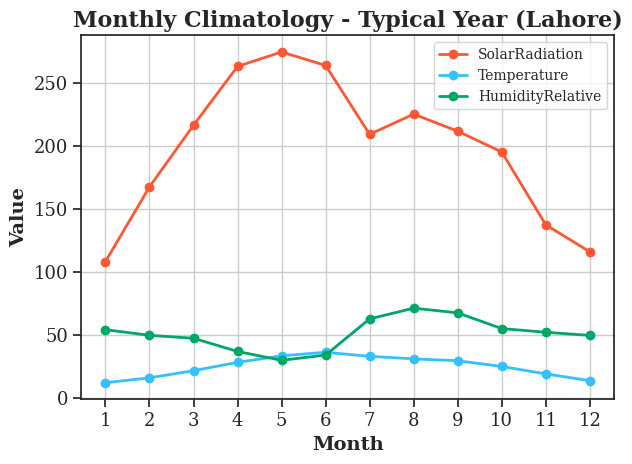

In [18]:
# ==========================================================
# Monthly Climatology - Typical Year (Lahore) - Enhanced Colors & Legend
# ==========================================================

monthly_clim = df.groupby(df.index.month).mean(numeric_only=True)

plt.figure(figsize=(10,6))

# Define bright colors for each variable
colors = {
    'SolarRadiation': '#FF5733',      # Bright red-orange
    'Temperature': '#33C1FF',         # Bright blue
    'HumidityRelative': '#00A868'     # Bright green
}

monthly_clim[['SolarRadiation', 'Temperature', 'HumidityRelative']].plot(
    marker='o',
    linewidth=2,
    color=[colors[col] for col in ['SolarRadiation', 'Temperature', 'HumidityRelative']],
    fontsize=13
)

plt.title("Monthly Climatology - Typical Year (Lahore)",
          fontsize=16, fontweight="bold")

plt.xlabel("Month", fontsize=14, fontweight="bold")
plt.ylabel("Value", fontsize=14, fontweight="bold")

plt.grid(True)
plt.xticks(monthly_clim.index, [str(m) for m in monthly_clim.index], fontsize=13)

# Move legend to upper right
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

**See how the diurnal pattern changes month to month. Reveals sunrise/sunset shift and seasonal daylight variation.**

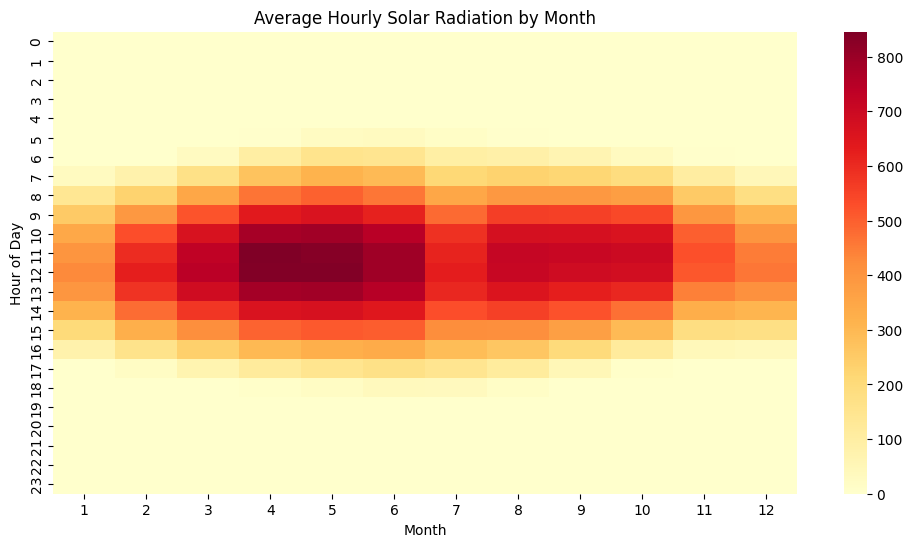

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.pivot_table(values='SolarRadiation',
                           index=df.index.hour,
                           columns=df.index.month,
                           aggfunc='mean'),
            cmap='YlOrRd')
plt.title('Average Hourly Solar Radiation by Month')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.show()


**Helps detect nonlinear relations or correlated predictors.**

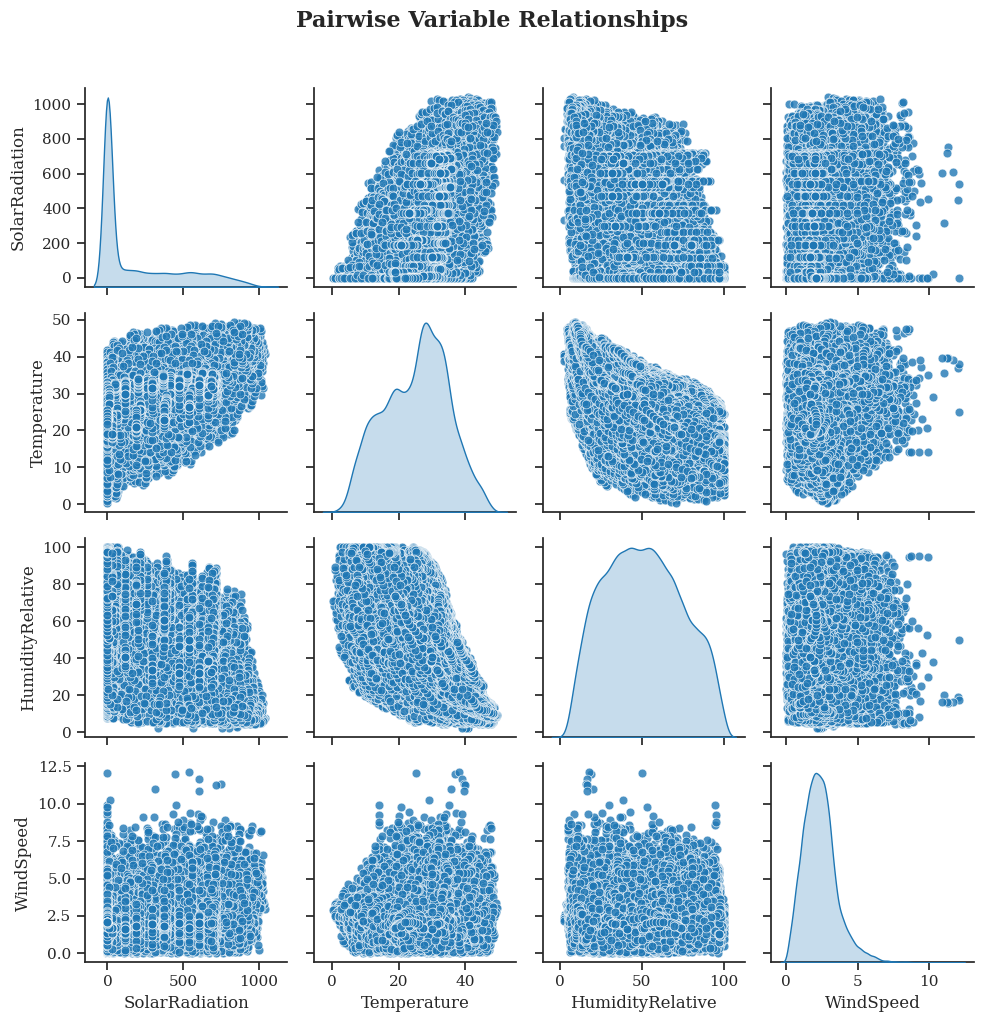

In [33]:
# ==========================================================
# Pairwise Variable Relationships - All Blue Color
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Variables to plot
vars_to_plot = ['SolarRadiation', 'Temperature', 'HumidityRelative', 'WindSpeed']

# Set global style and font
sns.set(style="ticks", font="serif")  # Serif font style

# Create the pairplot with blue color
pairplot = sns.pairplot(
    df[vars_to_plot],
    diag_kind='kde',                   # KDE on diagonal
    plot_kws={'alpha':0.8, 's':40, 'color':'#1f77b4'},  # Blue scatter points
    diag_kws={'fill':True, 'color':'#1f77b4'}           # Updated: fill instead of shade
)

# Update the suptitle
plt.suptitle(
    "Pairwise Variable Relationships",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

**Analyze wind direction/speed distributions. Reveals dominant wind direction patterns.**

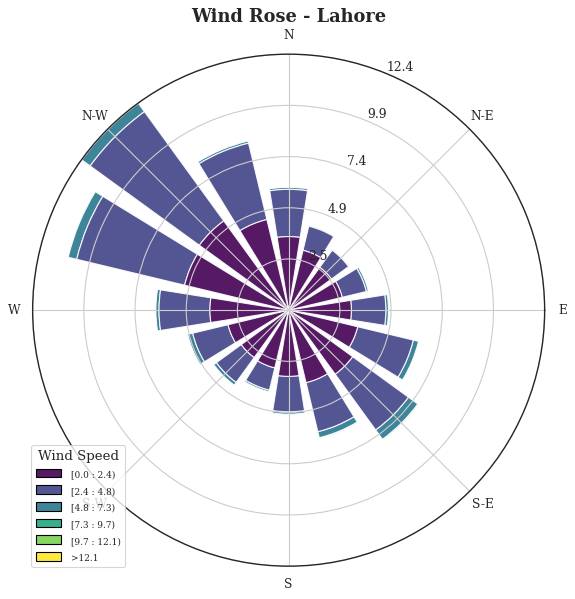

In [37]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Set global font style and size
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

# Create Windrose plot
ax = WindroseAxes.from_ax()

ax.bar(
    df['WindDirection'],
    df['WindSpeed'],
    normed=True,
    opening=0.8,
    edgecolor='white',
    alpha=0.9,
    cmap=plt.cm.viridis   # gradient color like your figure
)

# Title
ax.set_title("Wind Rose - Lahore", fontsize=16, fontweight='bold', y=1.05)

# Legend for wind speed bins
ax.set_legend(title="Wind Speed")

plt.show()

**Rolling Statistics (Moving Average): Identify slow-changing trends over time. Highlights long-term smoothing and anomalies.**

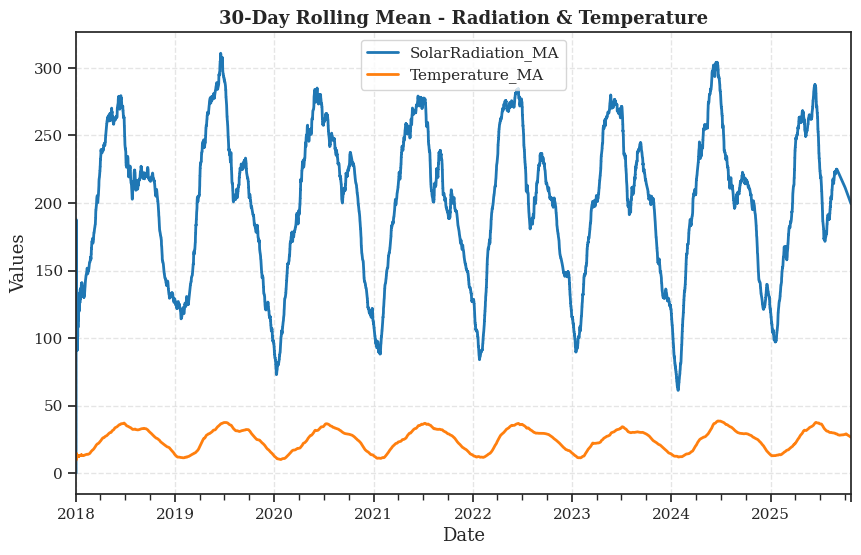

In [46]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

# Calculate 30-day rolling mean
df['SolarRadiation_MA'] = df['SolarRadiation'].rolling('30D').mean()
df['Temperature_MA'] = df['Temperature'].rolling('30D').mean()

# Plot
ax = df[['SolarRadiation_MA', 'Temperature_MA']].plot(
    figsize=(10,6),
    color=['#1f77b4', '#ff7f0e'],  # Matplotlib default blue & orange
    linewidth=2
)

ax.set_title('30-Day Rolling Mean - Radiation & Temperature', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Values', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Check Stationarity (for Time Series): Helps decide if differencing or detrending is needed.**


1.   No significant long-term upward or downward trend.
2.   Mean and variance are stable over time.
3.   Perfectly suitable for time-series models (like ARIMA, SARIMAX, Prophet, or LSTM) without differencing.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['SolarRadiation'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -14.305422432342818
p-value: 1.2091220799700876e-26


## **Modelling Hourly Forecasting**

In [ ]:
# ==========================================
# 🌤 Benchmark: XGBoost, RandomForest, LSTM, CNN-LSTM
# Save Models + Remove Transformer
# ==========================================

import os, gc, warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# create save directory
os.makedirs("saved_models", exist_ok=True)

# TF GPU memory growth (Colab safe)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

# ---------- 1. Load data ----------
df = pd.read_csv('lahore_hourly_filled.csv')
df.columns = df.columns.str.strip()

if 'datetime' not in df.columns:
    raise ValueError(f"'datetime' column not found")

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()

df = df.apply(pd.to_numeric, errors='coerce')

print("Loaded CSV range:", df.index.min(), "→", df.index.max())

required = ['ClearSkyRadiation','SolarRadiation','DirectRadiation','DiffuseRadiation',
            'SolarZenith','Temperature','HumiditySpecific','HumidityRelative',
            'Pressure','WindSpeed','WindDirection']

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError("Missing columns: ", missing)

df_day = df[df['SolarZenith'] < 90].copy()
df_day.dropna(subset=['SolarRadiation'], inplace=True)
df_day['hour'] = df_day.index.hour
df_day['month'] = df_day.index.month

target_col = 'SolarRadiation'
print("Daylight records:", len(df_day))

# ---------- 2. Train/Test split ----------
split_idx = int(len(df_day) * 0.8)
train = df_day.iloc[:split_idx].copy()
test  = df_day.iloc[split_idx:].copy()

# ---------- 3. Lag features ----------
MAX_LAG = 24

def make_lag_features(series_df, max_lag=24):
    cols_base = [target_col,'hour','month','Temperature','HumiditySpecific',
                 'HumidityRelative','Pressure','WindSpeed','WindDirection']
    df_feat = series_df[cols_base].copy()
    for lag in range(1, max_lag+1):
        df_feat[f"lag_{lag}"] = df_feat[target_col].shift(lag)
    return df_feat.dropna()

df_lag = make_lag_features(df_day, MAX_LAG)

train_lag = df_lag.loc[df_lag.index.intersection(train.index)]
test_lag  = df_lag.loc[df_lag.index.intersection(test.index)]

# fallback if no test rows
if len(test_lag) == 0:
    train_lag = df_lag.iloc[:-MAX_LAG].copy()
    test_lag  = df_lag.iloc[-MAX_LAG:].copy()

X_train_tree = train_lag.drop(columns=[target_col])
y_train_tree = train_lag[target_col]
X_test_tree  = test_lag.drop(columns=[target_col])
y_test       = test_lag[target_col]

# ---------- 4. Scaling for deep learning ----------
SEQ_LEN = 24
features = ['hour','month','Temperature','HumiditySpecific','HumidityRelative',
            'Pressure','WindSpeed','WindDirection', target_col]
df_seq = df_day[features].dropna()

train_seq_df = df_seq.loc[:train.index.max()]
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train_seq_df.drop(columns=[target_col]))
scaler_y.fit(train_seq_df[[target_col]])

# Save scalers
joblib.dump(scaler_X, "saved_models/scaler_X.pkl")
joblib.dump(scaler_y, "saved_models/scaler_y.pkl")

def create_sequences(df_in, seq_len=24):
    Xs, ys, idxs = [], [], []
    X_arr = scaler_X.transform(df_in.drop(columns=[target_col]))
    y_arr = scaler_y.transform(df_in[[target_col]]).flatten()

    for i in range(seq_len, len(df_in)):
        Xs.append(X_arr[i-seq_len:i])
        ys.append(y_arr[i])
        idxs.append(df_in.index[i])

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq_all, y_seq_all, idxs_all = create_sequences(df_seq)

train_idx_set = set(train.index)
test_idx_set  = set(test.index)

train_mask = np.array([idx in train_idx_set for idx in idxs_all])
test_mask  = np.array([idx in test_idx_set  for idx in idxs_all])

X_train_seq = X_seq_all[train_mask]
y_train_seq = y_seq_all[train_mask]
X_test_seq  = X_seq_all[test_mask]
y_test_seq  = y_seq_all[test_mask]

y_train_unscaled = scaler_y.inverse_transform(y_train_seq.reshape(-1,1)).flatten()
y_test_unscaled  = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

# ---------- RESULTS ----------
results = []

# ======================================
# 6. XGBoost
# ======================================
print("\n=== Training XGBoost ===")
xgb_model = xgb.XGBRegressor(
    n_estimators=800, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_model.fit(X_train_tree, y_train_tree)

# Save model
joblib.dump(xgb_model, "saved_models/xgboost_model.pkl")

xgb_train_pred = xgb_model.predict(X_train_tree)
xgb_test_pred  = xgb_model.predict(X_test_tree)

results.append([
    'XGBoost',
    r2_score(y_train_tree, xgb_train_pred),
    r2_score(y_test, xgb_test_pred),
    mean_absolute_error(y_test, xgb_test_pred),
    rmse(y_test, xgb_test_pred)
])

# ======================================
# 7. Random Forest
# ======================================
print("\n=== Training Random Forest ===")
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_tree, y_train_tree)

# Save model
joblib.dump(rf, "saved_models/random_forest_model.pkl")

rf_train_pred = rf.predict(X_train_tree)
rf_test_pred  = rf.predict(X_test_tree)

results.append([
    'Random Forest',
    r2_score(y_train_tree, rf_train_pred),
    r2_score(y_test, rf_test_pred),
    mean_absolute_error(y_test, rf_test_pred),
    rmse(y_test, rf_test_pred)
])

# ======================================
# 8. LSTM
# ======================================
print("\n=== Training LSTM ===")
K.clear_session()
lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

es = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

# Save model
lstm_model.save("saved_models/lstm_model.h5")

lstm_train_pred = scaler_y.inverse_transform(lstm_model.predict(X_train_seq))
lstm_test_pred  = scaler_y.inverse_transform(lstm_model.predict(X_test_seq))

lstm_train_pred = lstm_train_pred.flatten()
lstm_test_pred  = lstm_test_pred.flatten()

results.append([
    'LSTM',
    r2_score(y_train_unscaled, lstm_train_pred),
    r2_score(y_test_unscaled, lstm_test_pred),
    mean_absolute_error(y_test_unscaled, lstm_test_pred),
    rmse(y_test_unscaled, lstm_test_pred)
])

# ======================================
# 9. CNN-LSTM
# ======================================
print("\n=== Training CNN-LSTM ===")
K.clear_session()
inp = layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2]))
x = layers.Conv1D(32, 3, padding='same', activation='relu')(inp)
x = layers.MaxPool1D(2)(x)
x = layers.LSTM(48)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(24, activation='relu')(x)
out = layers.Dense(1)(x)

cnn_lstm_model = models.Model(inp, out)
cnn_lstm_model.compile(optimizer='adam', loss='mse')

cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

# Save model
cnn_lstm_model.save("saved_models/cnn_lstm_model.h5")

cnn_train_pred = scaler_y.inverse_transform(cnn_lstm_model.predict(X_train_seq))
cnn_test_pred  = scaler_y.inverse_transform(cnn_lstm_model.predict(X_test_seq))

cnn_train_pred = cnn_train_pred.flatten()
cnn_test_pred  = cnn_test_pred.flatten()

results.append([
    'CNN-LSTM',
    r2_score(y_train_unscaled, cnn_train_pred),
    r2_score(y_test_unscaled, cnn_test_pred),
    mean_absolute_error(y_test_unscaled, cnn_test_pred),
    rmse(y_test_unscaled, cnn_test_pred)
])

# ---------- 10. Final Results ----------
results_df = pd.DataFrame(results, columns=['Model','R2_Train','R2_Test','MAE_Test','RMSE_Test'])
print(results_df)
results_df.to_csv("saved_models/model_results.csv", index=False)

print("\n🎉 All models saved successfully in: saved_models/")



Loaded CSV range: 2018-01-01 00:00:00 → 2025-12-10 23:00:00
Daylight records: 13912

=== Training XGBoost ===

=== Training Random Forest ===

=== Training LSTM ===


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== Training CNN-LSTM ===


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
           Model  R2_Train   R2_Test   MAE_Test   RMSE_Test
0        XGBoost  0.995255  0.984802  21.148956   33.411270
1  Random Forest  0.993038  0.984101  21.914068   34.173322
2           LSTM  0.876743  0.846722  77.816966  106.107268
3       CNN-LSTM  0.883269  0.841865  77.835346  107.775190

🎉 All models saved successfully in: saved_models/


**Next 7 Day Forecast Beyond Data**

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb

# ---------- 1. Load data ----------
df = pd.read_csv('lahore_hourly_filled.csv', parse_dates=['datetime'], index_col='datetime')
df = df.sort_index().apply(pd.to_numeric, errors='coerce')

# daylight-only filter (for training)
df_day = df[df['SolarZenith'] < 90].copy()
df_day.dropna(subset=['SolarRadiation'], inplace=True)
df_day['hour'] = df_day.index.hour
df_day['month'] = df_day.index.month

target_col = 'SolarRadiation'

# ---------- 2. Lag features ----------
MAX_LAG = 24
def make_lag_features(series_df, max_lag=24):
    df_feat = series_df[[target_col,'hour','month','Temperature','HumiditySpecific',
                         'HumidityRelative','Pressure','WindSpeed','WindDirection']].copy()
    for lag in range(1, max_lag+1):
        df_feat[f"lag_{lag}"] = df_feat[target_col].shift(lag)
    return df_feat.dropna()

df_lag = make_lag_features(df_day, MAX_LAG)
X_train = df_lag.drop(columns=[target_col])
y_train = df_lag[target_col]

# ---------- 3. Train XGBoost ----------
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=2, verbosity=0
)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained.")

# ---------- 4. Forecast next 7 days (daylight hours only, 12h/day) ----------
last_time = df_day.index.max()
forecast_days = 7
daylight_hours = range(6, 18)  # 6 AM to 5 PM (12 hours)
forecast_results = []

forecast_input = df_day.iloc[-MAX_LAG:].copy()
expected_columns = forecast_input.columns.tolist()

for day in range(forecast_days):
    for hr in daylight_hours:
        # Create feature row
        row_data = {
            'hour': hr,
            'month': (last_time + pd.Timedelta(days=day)).month,
            'Temperature': forecast_input['Temperature'].iloc[-1],
            'HumiditySpecific': forecast_input['HumiditySpecific'].iloc[-1],
            'HumidityRelative': forecast_input['HumidityRelative'].iloc[-1],
            'Pressure': forecast_input['Pressure'].iloc[-1],
            'WindSpeed': forecast_input['WindSpeed'].iloc[-1],
            'WindDirection': forecast_input['WindDirection'].iloc[-1],
        }
        for lag in range(1, MAX_LAG+1):
            row_data[f'lag_{lag}'] = forecast_input['SolarRadiation'].iloc[-lag]

        X_pred = pd.DataFrame([row_data])
        X_pred = X_pred.reindex(columns=X_train.columns, fill_value=np.nan)
        y_pred = xgb_model.predict(X_pred)[0]
        forecast_results.append({
            'datetime': last_time + pd.Timedelta(days=day, hours=hr),
            'SolarRadiation_Forecast': y_pred
        })

        # Append prediction to forecast_input for next lag calculation
        new_row = {col: np.nan for col in expected_columns}
        new_row['SolarRadiation'] = y_pred
        new_row['hour'] = hr
        new_row['month'] = row_data['month']
        new_row['Temperature'] = row_data['Temperature']
        new_row['HumiditySpecific'] = row_data['HumiditySpecific']
        new_row['HumidityRelative'] = row_data['HumidityRelative']
        new_row['Pressure'] = row_data['Pressure']
        new_row['WindSpeed'] = row_data['WindSpeed']
        new_row['WindDirection'] = row_data['WindDirection']
        new_row_df = pd.DataFrame([new_row], index=[last_time + pd.Timedelta(days=day, hours=hr)])
        forecast_input = pd.concat([forecast_input, new_row_df])

# ---------- 5. Save forecast ----------
forecast_df = pd.DataFrame(forecast_results)
forecast_df.set_index('datetime', inplace=True)
forecast_df.to_csv('xgboost_7day_daylight_forecast.csv')
print("✅ 7-day daylight-only forecast saved to xgboost_7day_daylight_forecast.csv")
print(forecast_df.head(24))  # first 12-hour daylight of day 1


✅ XGBoost trained.
✅ 7-day daylight-only forecast saved to xgboost_7day_daylight_forecast.csv
                     SolarRadiation_Forecast
datetime                                    
2025-10-22 23:00:00                37.059315
2025-10-23 00:00:00               199.914749
2025-10-23 01:00:00               391.624847
2025-10-23 02:00:00               568.055664
2025-10-23 03:00:00               677.752686
2025-10-23 04:00:00               696.070190
2025-10-23 05:00:00               671.796875
2025-10-23 06:00:00               594.722168
2025-10-23 07:00:00               460.763702
2025-10-23 08:00:00               283.236847
2025-10-23 09:00:00               117.083389
2025-10-23 10:00:00                12.396963
2025-10-23 23:00:00                44.576225
2025-10-24 00:00:00               197.593567
2025-10-24 01:00:00               380.266602
2025-10-24 02:00:00               541.592407
2025-10-24 03:00:00               653.201416
2025-10-24 04:00:00               675.377319
2025-1

R2: 0.998, MAE: 6.64, RMSE: 11.80


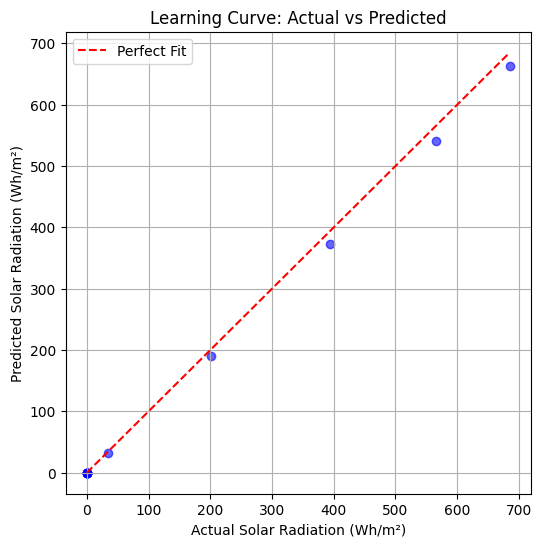

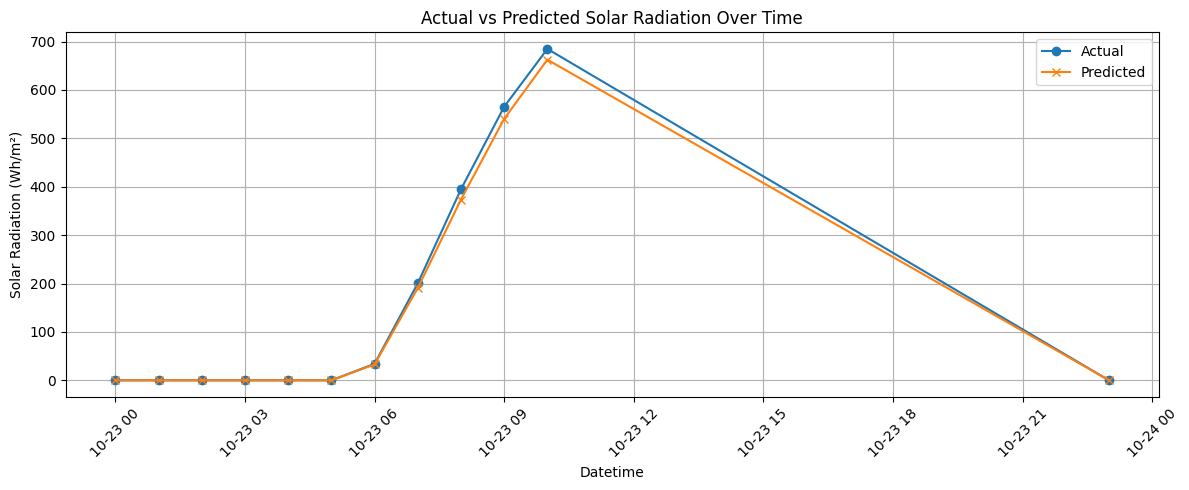

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# -------------------------------
# 1️⃣ Hardcoded XGBoost 7-day daylight forecast
# -------------------------------
data_xgb = {
    'datetime': [
        '2025-10-22 23:00:00','2025-10-23 00:00:00','2025-10-23 01:00:00','2025-10-23 02:00:00',
        '2025-10-23 03:00:00','2025-10-23 04:00:00','2025-10-23 05:00:00','2025-10-23 06:00:00',
        '2025-10-23 07:00:00','2025-10-23 08:00:00','2025-10-23 09:00:00','2025-10-23 10:00:00',
        '2025-10-23 23:00:00','2025-10-24 00:00:00','2025-10-24 01:00:00','2025-10-24 02:00:00',
        '2025-10-24 03:00:00','2025-10-24 04:00:00','2025-10-24 05:00:00','2025-10-24 06:00:00',
        '2025-10-24 07:00:00','2025-10-24 08:00:00','2025-10-24 09:00:00','2025-10-24 10:00:00'
    ],
    'SolarRadiation_Forecast': [
        37.059315,199.914749,391.624847,568.055664,677.752686,696.070190,671.796875,594.722168,
        460.763702,283.236847,117.083389,12.396963,44.576225,197.593567,380.266602,541.592407,
        653.201416,675.377319,646.658569,582.914124,453.450195,283.444031,113.446884,15.146305
    ]
}

df_pred = pd.DataFrame(data_xgb)
df_pred['datetime'] = pd.to_datetime(df_pred['datetime'])
df_pred.set_index('datetime', inplace=True)

# -------------------------------
# 2️⃣ Load actual daylight data
# -------------------------------
actual = pd.read_csv('one-week-extended-data.csv', index_col=0, parse_dates=True)
actual = actual.iloc[:24]  # Take same 12-hour cycle/daylight period for comparison

# -------------------------------
# 3️⃣ Align data
# -------------------------------
df_compare = actual.join(df_pred, how='inner')
df_compare.rename(columns={df_compare.columns[0]:'Actual', df_compare.columns[1]:'Predicted'}, inplace=True)

# -------------------------------
# 4️⃣ Compute Metrics
# -------------------------------
r2 = r2_score(df_compare['Actual'], df_compare['Predicted'])
mae = mean_absolute_error(df_compare['Actual'], df_compare['Predicted'])
rmse = np.sqrt(mean_squared_error(df_compare['Actual'], df_compare['Predicted']))

print(f"R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# -------------------------------
# 5️⃣ Scatter Plot: Actual vs Predicted
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(df_compare['Actual'], df_compare['Predicted'], color='blue', alpha=0.6)
plt.plot([df_compare['Actual'].min(), df_compare['Actual'].max()],
         [df_compare['Actual'].min(), df_compare['Actual'].max()],
         color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Solar Radiation (Wh/m²)')
plt.ylabel('Predicted Solar Radiation (Wh/m²)')
plt.title('Learning Curve: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 6️⃣ Line Plot: Actual vs Predicted Over Time
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_compare.index, df_compare['Actual'], label='Actual', marker='o')
plt.plot(df_compare.index, df_compare['Predicted'], label='Predicted', marker='x')
plt.xlabel('Datetime')
plt.ylabel('Solar Radiation (Wh/m²)')
plt.title('Actual vs Predicted Solar Radiation Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
